# Analisis Sentimen Komentar YouTube -- Pelemahan Rupiah

Proyek ini menganalisis sentimen komentar YouTube pada video tentang pelemahan Rupiah terhadap USD.
Tahapan: scraping komentar, labeling otomatis via LLM, preprocessing teks, analisis wordcloud & TF-IDF.

**Dataset:** 319 komentar dari video youtube.com/@leonardus_ragavan  
**Label:** positive (dukungan/pujian), neutral (informatif/opini), negative (kritik/sarkasme)

## 1. Scraping Komentar YouTube

In [2]:
import pandas as pd
from youtube_comment_downloader import YoutubeCommentDownloader

url = "https://youtu.be/j-mZRs8oqzk"

downloader = YoutubeCommentDownloader()
comments = downloader.get_comments_from_url(url)

data = []
for i, comment in enumerate(comments):
    if comment.get("reply"):
        continue
    # Bersihkan format votes (bisa "1.2K" atau "500")
    raw_votes = comment.get("votes", "0") or "0"
    if "K" in str(raw_votes):
        likes = int(float(raw_votes.replace("K", "")) * 1000)
    elif "M" in str(raw_votes):
        likes = int(float(raw_votes.replace("M", "")) * 1_000_000)
    else:
        try:
            likes = int(raw_votes)
        except ValueError:
            likes = 0

    data.append({
        "comment_id": comment.get("cid"),
        "text": comment.get("text"),
        "author": comment.get("author"),
        "likes": likes,
        "replies": comment.get("replies", 0),
        "time": comment.get("time"),
        "time_parsed": comment.get("time_parsed"),
    })
    if i >= 1000:
        break

df = pd.DataFrame(data)
print(f"Total komentar: {df.shape[0]}")
print(f"Sample:")
print(df[["text", "likes", "author"]].head(3))

df.to_csv("raw_comment.csv", index=False)
print(df.shape)

Total komentar: 321
Sample:
                                                text  likes             author
0             Ingat indon minimal beli nya 20 rb usd      0             @ibepe
1  Tahun 98 krisis moneter membuat kurs dollar me...      0  @chairulazhar6001
2  Tu rupiah menguat koq diam lu kima? Bahas dong...      0      @RIDWAN-c2b4z
(321, 7)


## 2. Labeling Sentimen via LLM

Menggunakan GPT-4o-mini untuk mengklasifikasikan komentar ke positive/neutral/negative.
Setiap komentar dikirim dengan prompt berisi konteks video + contoh (few-shot).
Response model dipotong dengan regex untuk mengambil label saja jika model tidak patuh instruksi.

In [6]:
import time, re, pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI(api_key=os.getenv("9ROUTERS_API_KEY"), 
                base_url="http://localhost:20128/v1",
                )

prompt = """Anda adalah analis sentimen komentar YouTube Indonesia. Klasifikasikan ke:

- positive : dukungan, pujian, persetujuan tulus
- neutral  : informatif, bertanya, opini tanpa emosi jelas
- negative : kritik, kecewa, marah, atau SARKASME

Balas HANYA dengan satu kata: positive / neutral / negative

Konteks video: pelemahan Rupiah (hingga Rp17.000+), kritik pajak & prioritas anggaran (MBG).
Mayoritas komentar sinis. Waspada sarkasme — ucapan terima kasih/emoji positif bisa menutupi kritik.

Contoh:
- "INDON tidak kena pajak bro LEON." → negative
- "Kuliah gratis. makasih koh 😊" → negative
- "kalau 17 845 indonesia merdeka kata PDIP" → negative
- "Penjelasannya ringan mudah diterima" → positive
- "Rupiah melemah karena sell off besar-besaran" → neutral"""

def extract_label(text):
    if not text or not isinstance(text, str):
        return None
    match = re.search(r'\b(positive|neutral|negative)\b', text.strip().lower())
    return match.group(1) if match else None

def classify_one(idx, text):
    try:
        response = client.chat.completions.create(
            model="openai/gpt-4o-mini",
            messages=[{"role": "system", "content": prompt}, {"role": "user", "content": text}]
        )
        label = extract_label(response.choices[0].message.content)
        return {"idx": idx, "text": text, "sentiment": label, "error": None if label else "unparseable"}
    except Exception as e:
        return {"idx": idx, "text": text, "sentiment": None, "error": str(e)}

In [7]:
df = pd.read_csv("raw_comment.csv")[["text"]].dropna()
df = df[df["text"].str.strip() != ""].reset_index(drop=True)
print(f"Total komentar: {len(df)}")

Total komentar: 321


Jalankan ketika belum memiliki/re-create data labelingnya, karena sudah ada maka tidak usah

In [ ]:
start = time.time()
results = [None] * len(df)

with ThreadPoolExecutor(max_workers=2) as executor:
    futures = {
        executor.submit(classify_one, i, row["text"]): i
        for i, row in df.iterrows()
    }
    with tqdm(total=len(df), desc="Classifying") as pbar:
        for future in as_completed(futures):
            try:
                result = future.result()
                if result.get("error"):
                    print(result["error"])
                results[result["idx"]] = result
                pbar.update(1)
            except Exception as e:
                print("THREAD ERROR:", e)

In [ ]:
result_df = pd.DataFrame(results)

# Drop baris yang gagal (API error atau response tidak mengandung label valid)
n_errors = result_df["sentiment"].isna().sum()
if n_errors > 0:
    print(f"{n_errors} komentar gagal -- akan di-drop")
    result_df = result_df.dropna(subset=["sentiment"]).reset_index(drop=True)

result_df[["text", "sentiment"]].to_csv(
    "../Data/Labeled(4)_comment.csv", index=False, encoding="utf-8-sig"
)
print(result_df["sentiment"].value_counts())

## 3. Load Hasil Labeling dan Eksplorasi Awal

In [9]:
import pandas as pd, numpy as np

df = pd.read_csv("../Data/Labeled(4)_comment.csv")
df.head(31)

,text,sentiment
0,"Hmm semua itu karena elite global, kalo mmg ka...",negative
1,"Loose lips sink ship. Ini krn regulasi, contoh...",negative
2,rupiah melemah karena sell off rupiah besar be...,neutral
3,"Laporan perusahaan robotech, duit tidak masuk,...",negative
4,"Labil banget yak, awalnya cm satu orang aja ng...",negative
5,"Terimakasih kontennya, sangat edukatif",positive
6,Pemerintah nya tuh yg nga becus mengurus negar...,negative
7,😂🤣😂🤣🤣😂🤣 pemerintahan penuh tipu-tipu? 😂😂🤣🤣 ad...,negative
8,Kyk Ngajarin anak kecil y kooh 🗿🗿 pke nyamain ...,negative
9,dari salah satu youtuber ada kebijakan Quantit...,neutral


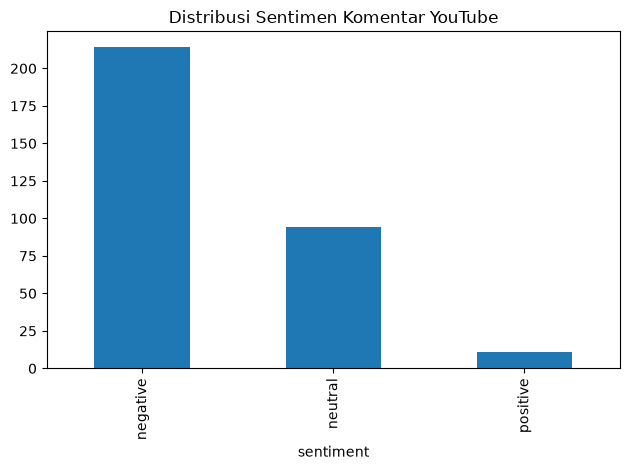

sentiment
negative    67.08
neutral     29.47
positive     3.45
Name: proportion, dtype: float64

In [10]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribusi Sentimen Komentar YouTube")
plt.tight_layout()
plt.show()

(df["sentiment"].value_counts(normalize=True) * 100).round(2)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       319 non-null    str  
 1   sentiment  319 non-null    str  
dtypes: str(2)
memory usage: 57.2 KB


## 4. Preprocessing

Tahapan: normalisasi slang via kamus publik (15rb+ entri), penghapusan stopwords,
normalisasi elongasi ("ambyarrr" jadi "ambyar"), dan penghapusan pola tawa ("wkwkwk").

Dua versi stopword: wordcloud (lebih agresif) dan TF-IDF (lebih konservatif).

In [12]:
import re, pandas as pd, stopwordsiso as stopwords

# Kamus slang publik (nasalsabila/kamus-alay, 15rb+ entri)
KAMUS_ALAY_URL = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
_slang_df = pd.read_csv(KAMUS_ALAY_URL)
slang_map = _slang_df.groupby("slang")["formal"].agg(lambda x: x.value_counts().idxmax()).to_dict()

slang_map.update({"dolar": "dollar", "rp": "rupiah", "idr": "rupiah", "indo": "indonesia"})

# Whitelist: istilah ekonomi yang jangan dinormalisasi
for term in {"mbg", "sby", "ihsg", "ojk", "fed"}:
    slang_map.pop(term, None)

# Manual merge kata kunci ekonomi (alternatif stemmer yang lebih aman)
slang_map.update({
    "melemah": "lemah", "pelemahan": "lemah", "melemahnya": "lemah",
    "menguat": "kuat", "penguatan": "kuat", "menguatnya": "kuat",
})

base_stopwords = set(stopwords.stopwords("id"))

stopword_wordcloud_extra = {
    "di", "dan", "yg", "yang", "gak", "gk", "cuma", "udah", "adalah",
    "dia", "ada", "masih", "mau", "sangat", "pasti", "tapi", "itu",
    "nya", "dari", "ke", "bisa", "kita", "dengan", "banyak", "jadi",
    "sama", "bang", "bro", "banget", "dgn", "dll", "bi", "aja", "sih",
    "nih", "untuk", "coba", "bikin", "bikn", "karena", "juga", "hmm",
    "krn", "gue", "gw", "kalo", "yak", "ya", "jd", "ga", "b", "rb",
    "atau", "saya", "aku", "lu", "ko", "si", "jg", "d", "c", "bukan",
    "mereka", "orang", "beli", "lagi", "harus", "oleh", "akan",
    "sekarang", "ku", "gimana", "leon", "utk", "emang", "emg", "yah",
    "loe", "karna", "koh", "nga", "tau", "dr", "semoga", "klo", "sdh",
    "pa", "pak", "pake", "tuh", "tidak", "tdk", "tidk",
}

tfidf_stopword_extra = {
    "di", "dan", "yang", "gak", "klo", "kalo", "ya", "kalau", "ga",
    "udah", "leon", "orang", "mata", "beli", "dari", "ke", "itu",
    "ini", "nya", "dll", "yah", "ku", "d", "lagi", "loe", "koh",
    "si", "tuh", "sdh", "b", "bikin", "bikn", "aja", "ada", "kita",
    "ko", "yg", "bi", "cuma", "no", "sih", "nih", "bang", "bro",
    "gue", "gw", "aku", "saya", "dong", "kok", "deh", "lho", "loh", "kan",
}

stopword_wordcloud = base_stopwords | stopword_wordcloud_extra
tfidf_stopword = base_stopwords | tfidf_stopword_extra

def normalize_elongation(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

def remove_laughter(text):
    return re.sub(r'\b(?:wk|ha|he|hi|xi)+\b', ' ', text)

def clean_text(text, stopword_set, slang_dict=slang_map):
    text = str(text).lower()
    text = re.sub(r'\\n|\\r', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = normalize_elongation(text)
    text = remove_laughter(text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    normalized = []
    for w in words:
        normalized.extend(slang_dict.get(w, w).split())
    return " ".join(w for w in normalized if w not in stopword_set and len(w) > 2)

df["wordcloud_text"] = df["text"].apply(lambda x: clean_text(x, stopword_wordcloud))
df["tfidf_text"] = df["text"].apply(lambda x: clean_text(x, tfidf_stopword))

In [13]:
print(df['wordcloud_text'].head(11))

0     elite global pemerintahan mbg zaman jokowi kor...
1     loose lips sink ship regulasi contoh biarkan s...
2        rupiah lemah sell off rupiah besaran singapura
3     laporan perusahaan robotech duit masuk moderen...
4     labil mengomong sell indonesia benaran indones...
5                        terimakasih kontennya edukatif
6     pemerintah becus mengurus negara mikirkan nega...
7     pemerintahan penuh tipu tipu adakah diandalkan...
8     kayak mengajari anak kooh pakai menyamakan ass...
9     salah youtuber kebijakan quantitative easing r...
10                                     indon kena pajak
Name: wordcloud_text, dtype: str


In [14]:
print(df["tfidf_text"].str.split().explode().value_counts().head(30))

tfidf_text
rupiah        87
dollar        73
indonesia     67
negara        48
lemah         47
pemerintah    37
uang          33
rakyat        32
usd           31
presiden      29
kuat          26
ekonomi       23
kayak         21
pakai         21
investor      20
negeri        19
desa          19
mbg           18
saham         17
kasih         17
turun         16
prabowo       16
harga         16
nilai         16
indon         15
pajak         15
impor         13
banget        13
korupsi       12
pejabat       12
Name: count, dtype: int64


In [15]:
n_empty = (df["tfidf_text"].str.strip() == "").sum()
print(f"Dokumen kosong setelah cleaning: {n_empty} dari {len(df)} — akan di-drop")
df = df[df["tfidf_text"].str.strip() != ""].reset_index(drop=True)

Dokumen kosong setelah cleaning: 4 dari 319 — akan di-drop


## 5. WordCloud per Sentimen

Visualisasi kata yang paling sering muncul untuk keseluruhan data dan per kelas sentimen.

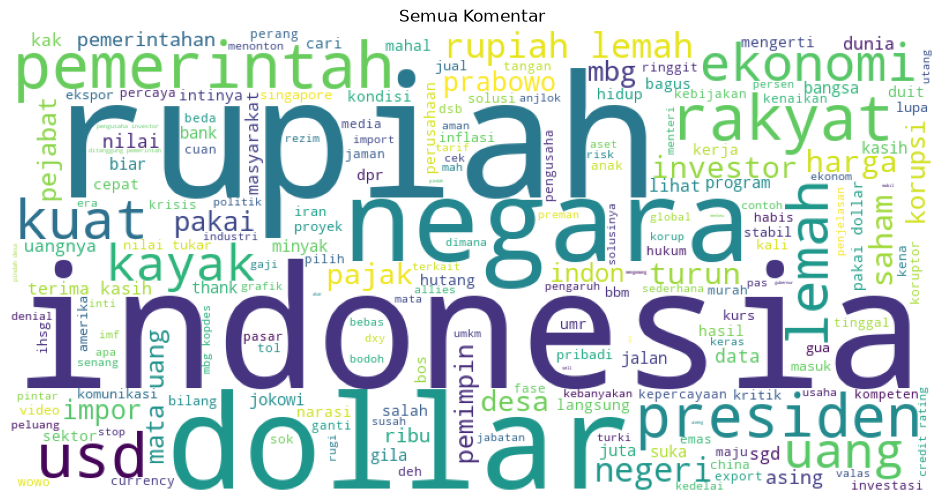

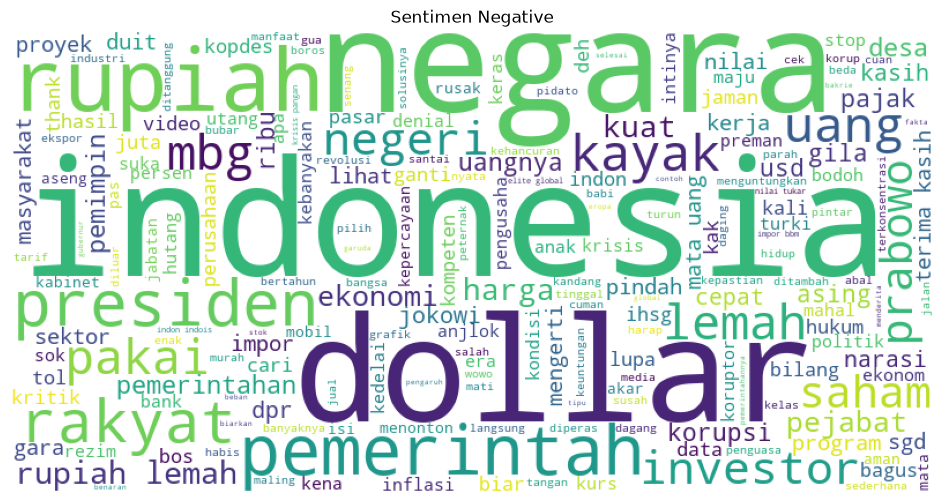

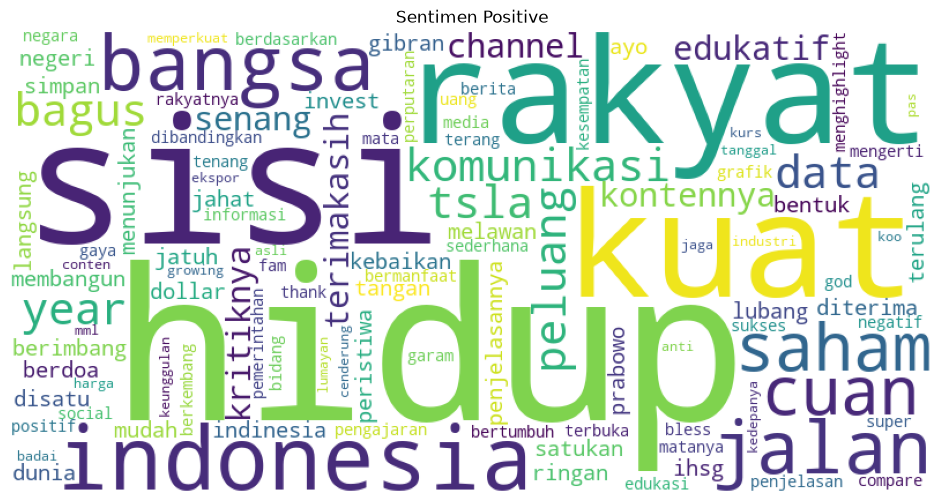

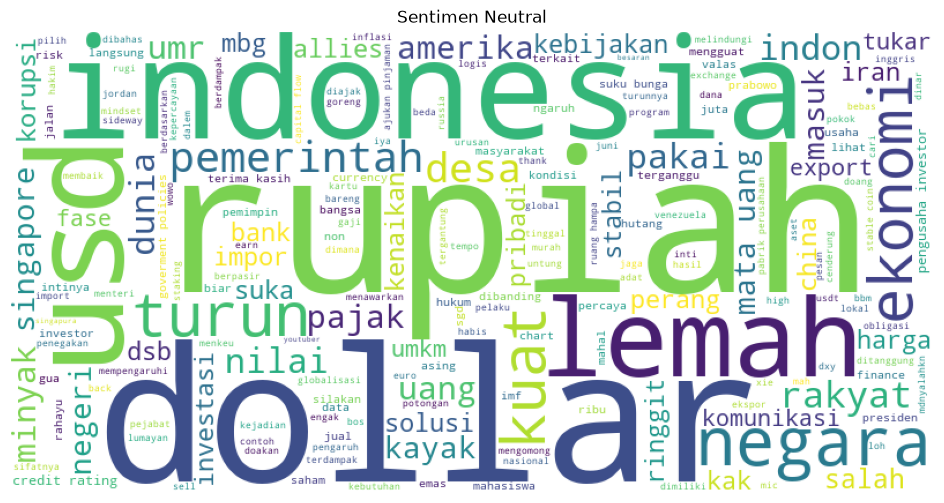

[('rupiah', 87), ('dollar', 73), ('indonesia', 67), ('negara', 48), ('lemah', 47), ('pemerintah', 37), ('uang', 33), ('rakyat', 32), ('usd', 31), ('presiden', 29), ('kuat', 26), ('ekonomi', 23), ('kayak', 21), ('pakai', 21), ('investor', 20), ('negeri', 19), ('desa', 19), ('mbg', 18), ('saham', 17), ('kasih', 17), ('turun', 16)]


In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

show_wordcloud(" ".join(df["wordcloud_text"]), "Semua Komentar")

negative_wc = " ".join(df[df["sentiment"] == "negative"]["wordcloud_text"])
show_wordcloud(negative_wc, "Sentimen Negative")

positive_wc = " ".join(df[df["sentiment"] == "positive"]["wordcloud_text"])
show_wordcloud(positive_wc, "Sentimen Positive")

neutral_wc = " ".join(df[df["sentiment"] == "neutral"]["wordcloud_text"])
show_wordcloud(neutral_wc, "Sentimen Neutral")

# Top words secara keseluruhan
from collections import Counter
words = Counter(" ".join(df["wordcloud_text"]).split())
print(words.most_common(21))

## 6. TF-IDF per Sentimen

TF-IDF di-fit sekali di seluruh korpus, lalu di-slice per kelas sentimen.
Pendekatan ini lebih fair daripada fit ulang per subset (IDF jadi tidak stabil, apalagi untuk kelas kecil seperti positive yang hanya 11 dokumen).

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100, min_df=3, max_df=0.5)
x = tfidf.fit_transform(df["tfidf_text"])
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['asing' 'bagus' 'banget' 'bangsa' 'bank' 'bbm' 'biar' 'bilang' 'bos'
 'cari' 'cepat' 'coba' 'data' 'desa' 'dollar' 'dpr' 'duit' 'dunia'
 'ekonomi' 'ekspor']


In [18]:
# Rata-rata TF-IDF global
tfidf_df = pd.DataFrame(x.toarray(), columns=feature_names)
tfidf_df.mean().sort_values(ascending=False).head(21)

rupiah        0.070552
indonesia     0.059380
dollar        0.053243
lemah         0.047955
negara        0.040802
presiden      0.035283
pemerintah    0.034325
rakyat        0.030139
kuat          0.028796
usd           0.028081
kasih         0.027585
uang          0.027291
desa          0.024715
indon         0.024004
pakai         0.023666
mbg           0.023168
prabowo       0.022734
kayak         0.022616
investor      0.020520
pejabat       0.020364
saham         0.020018
dtype: float64

In [19]:
# Slice per sentimen
def top_keywords_by_sentiment(label, n=20):
    mask = (df["sentiment"] == label).values
    x_subset = x[mask]
    scores = pd.DataFrame(x_subset.mean(axis=0).A1, index=feature_names, columns=["score"])
    return scores.sort_values("score", ascending=False).head(n)

keywords_neg = top_keywords_by_sentiment("negative")
keywords_pos = top_keywords_by_sentiment("positive")
keywords_neu = top_keywords_by_sentiment("neutral")

print("Negative:")
print(keywords_neg)
print("\nPositive:")
print(keywords_pos)
print("\nNeutral:")
print(keywords_neu)

Negative:
               score
indonesia   0.062215
rupiah      0.052225
presiden    0.046405
negara      0.042135
lemah       0.041786
dollar      0.040418
pemerintah  0.039310
rakyat      0.035726
kasih       0.033744
mbg         0.029761
kayak       0.028601
prabowo     0.027952
pejabat     0.026018
indon       0.025885
pakai       0.025662
uang        0.025251
pemimpin    0.024352
investor    0.022410
terima      0.022039
saham       0.020736

Positive:
                 score
bagus         0.137111
saham         0.102601
jalan         0.092201
semoga        0.090909
data          0.082127
kurs          0.065288
harga         0.064888
ekspor        0.063261
hidup         0.060245
ihsg          0.046112
pemerintahan  0.043997
langsung      0.043440
you           0.041183
mengerti      0.041183
thank         0.041183
bangsa        0.038916
uang          0.031378
rakyat        0.029651
kuat          0.028616
dollar        0.027191

Neutral:
               score
rupiah      0.121220
dol

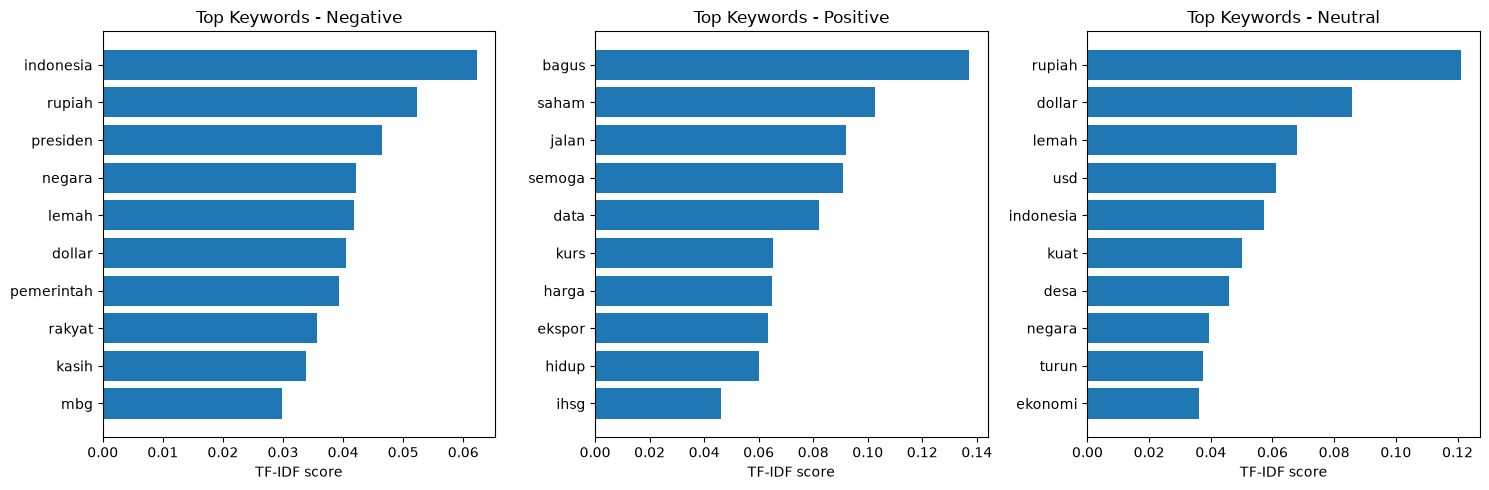

In [20]:
# Bar chart perbandingan top keywords tiap sentimen
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, kw) in zip(axes, [
    ("Negative", keywords_neg.head(10)),
    ("Positive", keywords_pos.head(10)),
    ("Neutral", keywords_neu.head(10))
]):
    kw = kw.sort_values("score")
    ax.barh(kw.index, kw["score"])
    ax.set_title(f"Top Keywords - {label}")
    ax.set_xlabel("TF-IDF score")
plt.tight_layout()
plt.show()

In [21]:
df[["text", "tfidf_text"]].sample(10)

,text,tfidf_text
171,"Edukasi yang sangat bermanfaat, semoga sukses ...",edukasi bermanfaat semoga sukses
119,Apa yg mau diharapkan sama pemimpin yg gak kom...,diharapkan pemimpin kompeten
118,"panggil hengky dulu, mau denger dia soal Saham...",panggil hengky dengar saham wkwkwkwkwkwkwkwkw
288,Qta selalu mncari masalah tuk diri cndiri. Bua...,mncari cndiri mbg hitungan implementasiny kaca...
53,"Thank u utk kuliahnya, ko Leon 🙏🏾🙏🏾🙏🏾",thank kuliahnya
104,Ringgit Kukuh mnakala Rupiah lemah ..Bgitulah ...,ringgit kukuh mnakala rupiah lemah bgitulah ne...
13,Apa karena menkeu menolak meminjam dr IMF maka...,menkeu menolak meminjam imf makannya rupiah lemah
32,"Kalau Danamas Dollar, bisa langsung buka akun ...",danamas dollar langsung buka akun sinarmas ban...
129,eMBeGeeeeeeeeeeeee...... \r\nHidup jokowiiiiii...,embege hidup jokowi dipikirannya hebat ketua k...
21,Menurut ku sih saat ini dollar sedang menguat ...,dollar kuat aux usd


## 7. Kesimpulan

1. **Distribusi sentimen** tidak seimbang: negative 67%, neutral 29%, positive 3.4%.
   Hal ini wajar karena video membahas pelemahan Rupiah yang memicu kekhawatiran dan kritik.

2. **Topik dominan** yang muncul di komentar negative: presiden, pemerintah, pajak, MBG,
   korupsi, dan nama tokoh (Prabowo, Jokowi). Sentimen positive lebih jarang dan
   umumnya berupa apresiasi terhadap konten edukatif channel.

3. **Keterbatasan dataset:** 319 komentar dari 1 video saja membuat analisis belum
   mencakup variasi topik yang lebih luas. Untuk pengembangan selanjutnya bisa
   menambahkan data dari sumber lain (multi-video, multi-channel).

4. **Untuk deployment:** model klasifikasi berbasis Logistic Regression + TF-IDF
   telah dibangun di notebook terpisah (Modeling.ipynb) dan dideploy via Streamlit
   (app.py) untuk prediksi interaktif.